<Axes: >

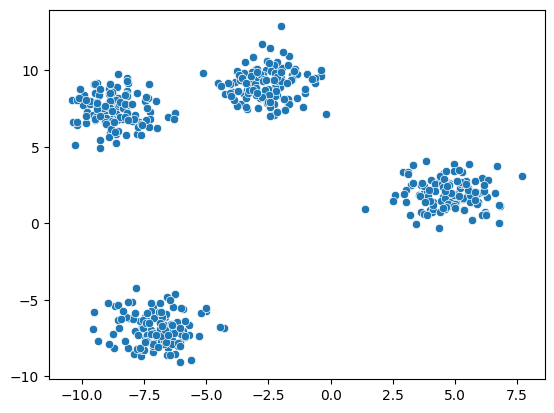

In [3]:
import seaborn as sns
from sklearn.datasets import make_blobs

x,y=make_blobs(
    n_samples=500,
    n_features=2,
    random_state=42,
    centers=4)
sns.scatterplot(x=x[:,0],y=x[:,1])

<Axes: >

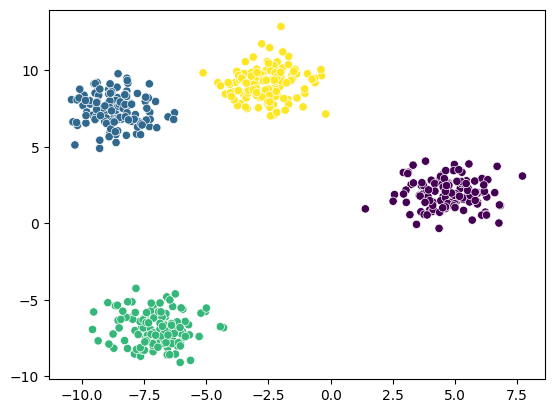

In [8]:
from sklearn.cluster import KMeans
k=4
kmeans=KMeans(n_clusters=k,random_state=42)
lables=kmeans.fit_predict(x,y)
sns.scatterplot(x=x[:,0],y=x[:,1],c=lables)

# Choosing Optimal K --> Elbow method && Silhouette Score

<Axes: >

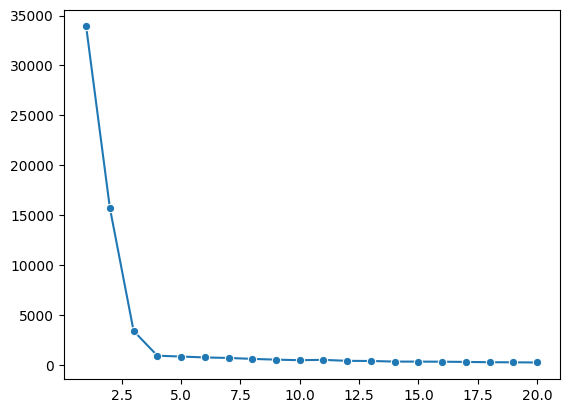

In [12]:
# Elbow method
wcss=[]
for k in range(1,21):
    kmeans=KMeans(k)
    kmeans.fit_predict(x)
    wcss.append(kmeans.inertia_)
sns.lineplot(x=range(1,21),y=wcss,marker='o')

In [ ]:
## optimal value is found at k=4..as elbow is at k=4

In [13]:
#ELBOW METHOD DIRECT CODE
!pip install kneed


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from kneed import KneeLocator
knee=KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")

In [15]:
print("Optimal k : ",knee.elbow)

Optimal k :  4


# silhouette score

<Axes: >

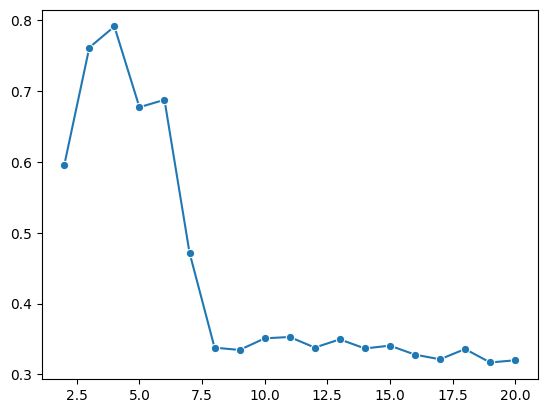

In [19]:
from sklearn.metrics import silhouette_score
ss=[]

for k in range(2,21):
    kmeans=KMeans(k)
    lables=kmeans.fit_predict(x)
    s=silhouette_score(x,lables)
    ss.append(s)

sns.lineplot(x=range(2,21),y=ss,marker='o')

In [ ]:
## highest silhouette score is at k=4,,,higher the silhouette score higher the 